In [1]:
%pip install -q librosa numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import glob
import pickle
import numpy as np
import scipy.ndimage
import scipy.signal
import matplotlib.pyplot as plt
import librosa
import argparse
from collections import Counter

In [3]:
print("Loading existing databases...")
with open("song_db.pkl", 'rb') as f:
    database = pickle.load(f)
with open("song_db_single.pkl", 'rb') as f:
    db_single = pickle.load(f)

Loading existing databases...


In [4]:
def compute_spectrogram(audio_path=None, y=None, sr=None,window_length=2048, hop_length=512,max_freq=3500):
    """
    Loads an audio file and computes its STFT spectrogram.
    Returns only frequency bins from 0 Hz to max_freq.
    """
    
    if y is None:
        y, sr = librosa.load(audio_path, sr=None, mono=True)

    # STFT
    stft_matrix = librosa.stft(
        y,
        n_fft=window_length,
        hop_length=hop_length,
        window='hann'
    )

    # Magnitude spectrogram
    S_mag = np.abs(stft_matrix)

    # Frequency bins
    freq_bins = librosa.fft_frequencies(sr=sr, n_fft=window_length)

    # Keep only frequencies <= max_freq
    freq_mask = freq_bins <= max_freq

    S_mag = S_mag[freq_mask, :]
    freq_bins = freq_bins[freq_mask]

    # Convert to dB scale
    S_db = librosa.amplitude_to_db(S_mag, ref=np.max)

    # Time bins
    time_bins = librosa.frames_to_time(
        np.arange(S_db.shape[1]),
        sr=sr,
        hop_length=hop_length
    )

    return S_db, freq_bins, time_bins, y, sr

In [5]:
def extract_peaks(spectrogram, freq_bins, time_bins, amp_threshold=-30, neighborhood_size=(20, 20)):
    """
    Finds local maxima in the spectrogram that stand out from their neighborhood.
    Returns a list of (time_idx, freq_idx) tuples.
    """
    # Create a boolean mask of local maxima
    local_max = scipy.ndimage.maximum_filter(spectrogram, size=neighborhood_size) == spectrogram
    
    # Filter out quiet peaks (background noise) using amplitude threshold
    background = (spectrogram == 0)
    eroded_background = scipy.ndimage.binary_erosion(background, structure=np.ones((1, 1)), border_value=1)
    
    # Apply thresholds
    peaks_mask = local_max ^ eroded_background
    amplitudes = spectrogram[peaks_mask]
    
    # Get peak coordinates
    freq_idx, time_idx = np.where(peaks_mask & (spectrogram > amp_threshold))
    
    # Sort peaks chronologically for sequential hashing
    sort_idx = np.argsort(time_idx)
    peaks = list(zip(time_idx[sort_idx], freq_idx[sort_idx]))
    
    return peaks

In [6]:
def generate_hashes(peaks, fan_out=15, time_delta_min=1, time_delta_max=100):
    """
    Pairs each peak with its 'fan_out' neighbors to create a combinatorial hash.
    Returns a list of (hash_string, time_offset_of_first_peak).
    """
    hashes = []
    num_peaks = len(peaks)
    
    for i in range(num_peaks):
        t1, f1 = peaks[i]
        
        # Look ahead up to 'fan_out' peaks
        for j in range(1, fan_out + 1):
            if i + j < num_peaks:
                t2, f2 = peaks[i + j]
                delta_t = t2 - t1
                
                # Enforce bounds on the time gap between paired peaks
                if time_delta_min <= delta_t <= time_delta_max:
                    # Create a stable string hash (built-in hash() randomizes per session)
                    hash_str = f"{f1}|{f2}|{delta_t}"
                    hashes.append((hash_str, t1))
    return hashes

def generate_hashes_single(peaks):
    """Single peak baseline hash (just the frequency)."""
    return [(str(f), t) for t, f in peaks]

In [7]:
def build_database(song_folder, use_pairs=True, db_path="song_db.pkl"):
    """
    Processes all .mp3 files in the folder and builds the hash database.
    """
    database = {}
    songs = glob.glob(os.path.join(song_folder, "*.mp3"))
    
    print(f"Indexing {len(songs)} songs...")
    for file_path in songs:
        song_name = os.path.basename(file_path).replace('.mp3', '')
        
        # Process audio pipeline
        S_db, f_bins, t_bins, _, _ = compute_spectrogram(file_path)
        peaks = extract_peaks(S_db, f_bins, t_bins)
        
        if use_pairs:
            hashes = generate_hashes(peaks)
        else:
            hashes = generate_hashes_single(peaks)
            
        # Insert into database
        for hash_val, t_offset in hashes:
            if hash_val not in database:
                database[hash_val] = []
            database[hash_val].append((song_name, t_offset))
            
    # Save to disk
    with open(db_path, 'wb') as f:
        pickle.dump(database, f)
        
    print(f"Database saved to {db_path} with {len(database)} unique hashes.")
    return database

In [8]:
def identify_song(y, sr, database, use_pairs=True):
    """
    Identifies a song from an audio array by matching hashes against the database.
    """
    S_db, f_bins, t_bins, _, _ = compute_spectrogram(y=y, sr=sr)
    peaks = extract_peaks(S_db, f_bins, t_bins)
    
    if use_pairs:
        hashes = generate_hashes(peaks)
    else:
        hashes = generate_hashes_single(peaks)
        
    matches = []
    for hash_val, t_query in hashes:
        if hash_val in database:
            for song_name, t_db in database[hash_val]:
                # Calculate the relative time offset
                delta_t = t_db - t_query
                matches.append((song_name, delta_t))
                
    if not matches:
        return None, {}

    # Accumulate matches to find the song/offset with the most hits
    match_counts = Counter(matches)
    best_match, max_score = match_counts.most_common(1)[0]
    best_song = best_match[0]
    
    # Build histogram data for the winning song to visualize later
    winning_offsets = [offset for (song, offset) in matches if song == best_song]
    
    return best_song, winning_offsets

In [9]:
def test_noise_robustness(query_path, database, snr_levels=[30, 20, 10, 5, 0]):
    """
    Adds white Gaussian noise to a query clip and checks identification.
    Assumes query_path points to a short 10-15s clip.
    """
    # Load the short query
    y, sr = librosa.load(query_path, sr=None, mono=True)
    signal_power = np.mean(y**2)
    
    for snr in snr_levels:
        # Calculate noise power needed for desired SNR
        snr_linear = 10**(snr / 10.0)
        noise_power = signal_power / snr_linear
        noise = np.random.normal(0, np.sqrt(noise_power), len(y))
        
        y_noisy = y + noise
        
        # Identify
        prediction, _ = identify_song(y_noisy, sr, database)
        print(f"SNR: {snr:02d}dB -> Predicted: {prediction}")
        
        # Memory cleanup
        del y_noisy, noise
        gc.collect()
        
    del y # Final cleanup

def test_pitch_shift(query_path, database, semitones_list=[-2, -1, 0, 1, 2]):
    """
    Shifts the pitch of a query clip and checks identification.
    Assumes query_path points to a short 10-15s clip.
    """
    # Load the short query
    y, sr = librosa.load(query_path, sr=None, mono=True)
    
    print("\n--- Pitch Shift Test ---")
    for steps in semitones_list:
        if steps == 0:
            y_shifted = y
        else:
            # Safe to run because 'y' is only 15 seconds long
            y_shifted = librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)
            
        # Identify
        prediction, _ = identify_song(y_shifted, sr, database)
        print(f"Pitch Shift: {steps:2d} semitones -> Predicted: {prediction}")
        
        # Memory cleanup
        if steps != 0:
            del y_shifted
        gc.collect()
    del y # Final cleanup
        
def test_time_stretch(query_path, database,
                      rates=[0.9, 0.95, 1.0, 1.05, 1.1]):

    y, sr = librosa.load(query_path, sr=None)

    print("\n--- Time Stretch Test ---")

    for rate in rates:

        if rate == 1.0:
            y_mod = y
        else:
            y_mod = librosa.effects.time_stretch(y, rate=rate)

        pred, _ = identify_song(y_mod, sr, database)

        print(f"Rate={rate:.2f} -> {pred}")
    del y # Final cleanup


In [10]:
def get_hash_pairs(peaks, fanout=5, max_pairs=300):
    pairs = []

    for i in range(len(peaks)):
        t1, f1 = peaks[i]

        for j in range(i+1, min(i+fanout+1, len(peaks))):
            t2, f2 = peaks[j]

            pairs.append(((t1, f1), (t2, f2)))

            if len(pairs) >= max_pairs:
                return pairs

    return pairs

In [11]:
def plot_full_analysis(audio_path, database, duration=30.0):
    """Produces the 4-panel matplotlib figure requested (truncated for memory safety)."""
    print(f"Loading first {duration} seconds for visualization...")
    
    # FIX 1: Only load a short snippet to prevent matplotlib from choking on massive arrays
    y, sr = librosa.load(audio_path, sr=None, mono=True, duration=duration)
    S_db, f_bins, t_bins, _, _ = compute_spectrogram(y=y, sr=sr)
    peaks = extract_peaks(S_db, f_bins, t_bins)
    prediction, offsets = identify_song(y, sr, database)
    
    plt.style.use('dark_background')
    fig, axs = plt.subplots(2,2, figsize=(15, 10)) 
   
    # (a) Constellation
    axs[0, 0].imshow(S_db,aspect='auto',origin='lower',cmap='magma',alpha=1,extent=[t_bins[0],t_bins[-1],f_bins[0],f_bins[-1]])

    if peaks:
        t_idx, f_idx = zip(*peaks)

        peak_times = t_bins[list(t_idx)]
        peak_freqs = f_bins[list(f_idx)]

        axs[0, 0].scatter(peak_times,peak_freqs,s=10,marker='o',facecolors='none',edgecolors='cyan')

    axs[0, 0].set_title("Constellation of Peaks")
    axs[0, 0].set_xlabel("Time (s)")
    axs[0, 0].set_ylabel("Frequency (Hz)")
    
    # (b) Fingerprint Hash Pairs

    axs[0,1].imshow(
        S_db,
        aspect='auto',
        origin='lower',
        cmap='magma',
        alpha=1,
        extent=[t_bins[0], t_bins[-1], f_bins[0], f_bins[-1]]
    )

    if peaks:

        t_idx, f_idx = zip(*peaks)

        peak_times = t_bins[list(t_idx)]
        peak_freqs = f_bins[list(f_idx)]

        # draw peaks
        axs[0,1].scatter(
            peak_times,
            peak_freqs,
            s=8,
            color='cyan'
        )

        # draw fingerprint connections
        hash_pairs = get_hash_pairs(peaks)

        for (t1_idx, f1_idx), (t2_idx, f2_idx) in hash_pairs:

            axs[0,1].plot(
                [t_bins[t1_idx], t_bins[t2_idx]],
                [f_bins[f1_idx], f_bins[f2_idx]],
                color='yellow',
                alpha=0.15,
                linewidth=0.5
            )

    axs[0,1].set_title("Fingerprint Hash Pairs")
    axs[0,1].set_xlabel("Time (s)")
    axs[0,1].set_ylabel("Frequency (Hz)")
    
    # (c) Offset Histogram
    if offsets:
        axs[1, 0].hist(offsets, bins=50, color='purple', edgecolor='black')
        axs[1, 0].set_title(f"Offset Histogram for '{prediction}'")
        axs[1, 0].set_xlabel("Time Offset Delta (frames)")
        axs[1, 0].set_ylabel("Match Frequency")
    else:
        axs[1, 0].text(0.5, 0.5, "No Matches Found", ha='center', va='center')
        axs[1, 0].set_title("Offset Histogram")

    # (d) Fingerprint
    axs[1, 1].imshow(S_db,aspect='auto',origin='lower',alpha=0,extent=[t_bins[0],t_bins[-1],f_bins[0],f_bins[-1]])

    if peaks:
        t_idx, f_idx = zip(*peaks)

        peak_times = t_bins[list(t_idx)]
        peak_freqs = f_bins[list(f_idx)]

        axs[1, 1].scatter(peak_times,peak_freqs,s=10,marker='o',facecolors='none',edgecolors='cyan')

    axs[1, 1].set_title("Fingerprint")
    axs[1, 1].set_xlabel("Time (s)")
    axs[1, 1].set_ylabel("Frequency (Hz)")

    plt.tight_layout()
    plt.show()
    
    # FIX 2: Explicitly close the figure and free memory
    plt.close(fig)
    del y, S_db, fig, axs
    gc.collect()
    print(f"Number of peaks detected: {len(peaks)}")

Loading first 30.0 seconds for visualization...


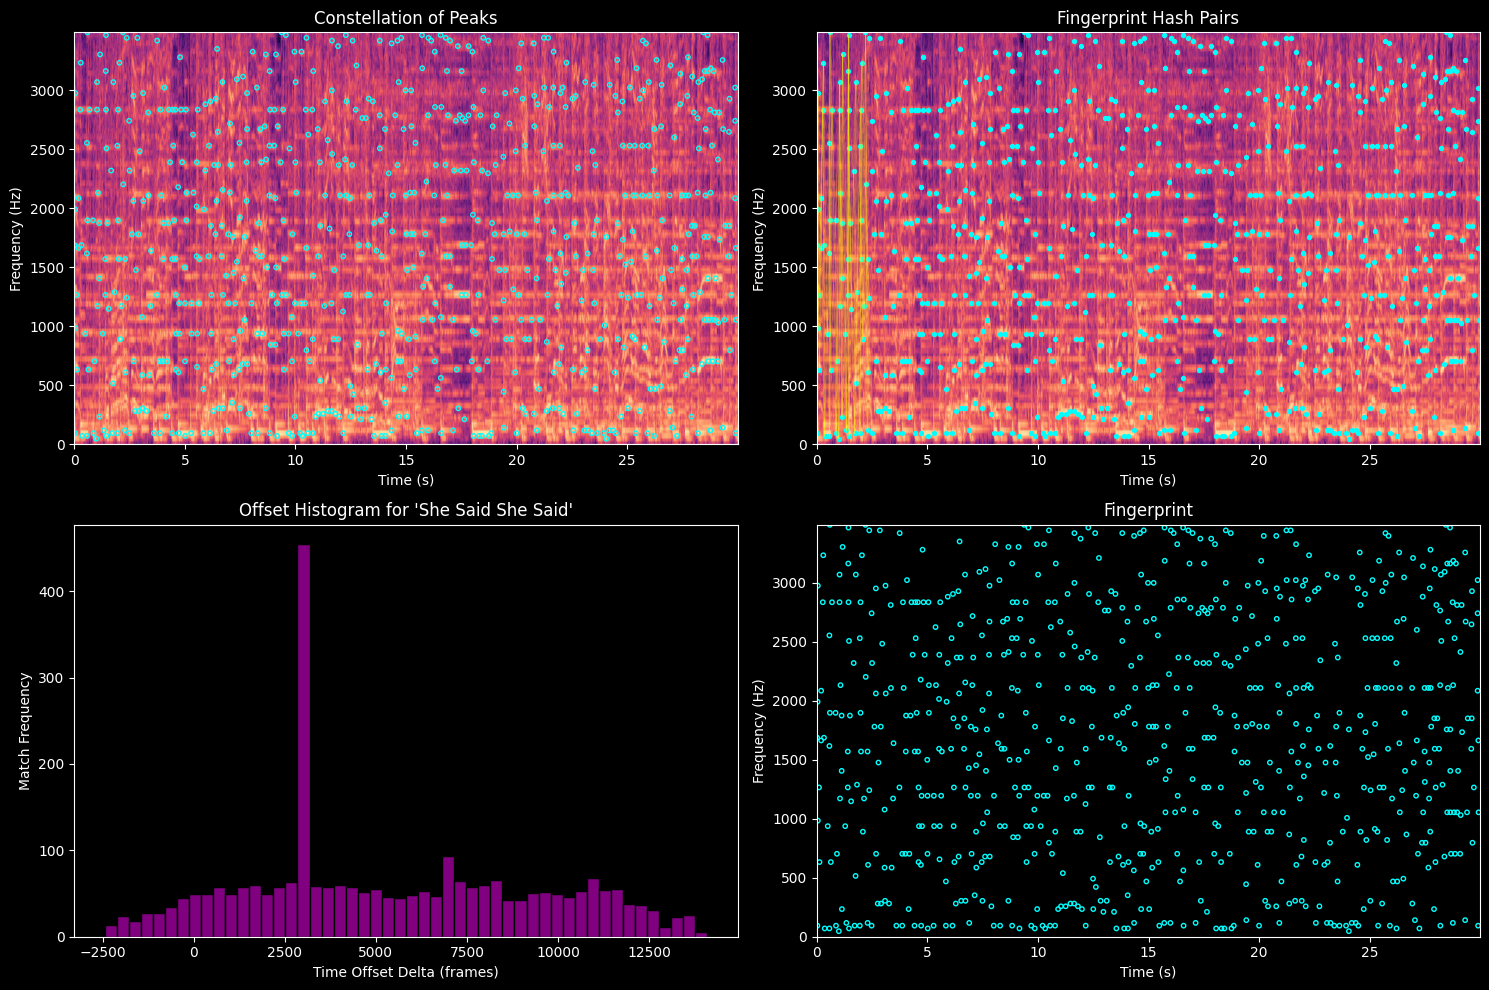

Number of peaks detected: 743


In [12]:
plot_full_analysis("query_clip.mp3", database)


--- Identifying Query ---
Result: She Said She Said

--- Robustness Experiments ---
Noise Test:
SNR: 30dB -> Predicted: She Said She Said
SNR: 20dB -> Predicted: She Said She Said
SNR: 10dB -> Predicted: She Said She Said
SNR: 05dB -> Predicted: She Said She Said
SNR: 00dB -> Predicted: She Said She Said

Pitch Shift Test:

--- Pitch Shift Test ---
Pitch Shift: -2 semitones -> Predicted: Across The Universe
Pitch Shift: -1 semitones -> Predicted: Crazy Little Thing Called Love
Pitch Shift:  0 semitones -> Predicted: She Said She Said
Pitch Shift:  1 semitones -> Predicted: While My Guitar Gently Weeps
Pitch Shift:  2 semitones -> Predicted: Let It Be

Time Stretch Test:

--- Time Stretch Test ---
Rate=0.90 -> She Said She Said
Rate=0.95 -> She Said She Said
Rate=1.00 -> She Said She Said
Rate=1.05 -> She Said She Said
Rate=1.10 -> Two Of Us

--- Visualization ---
Loading first 30.0 seconds for visualization...


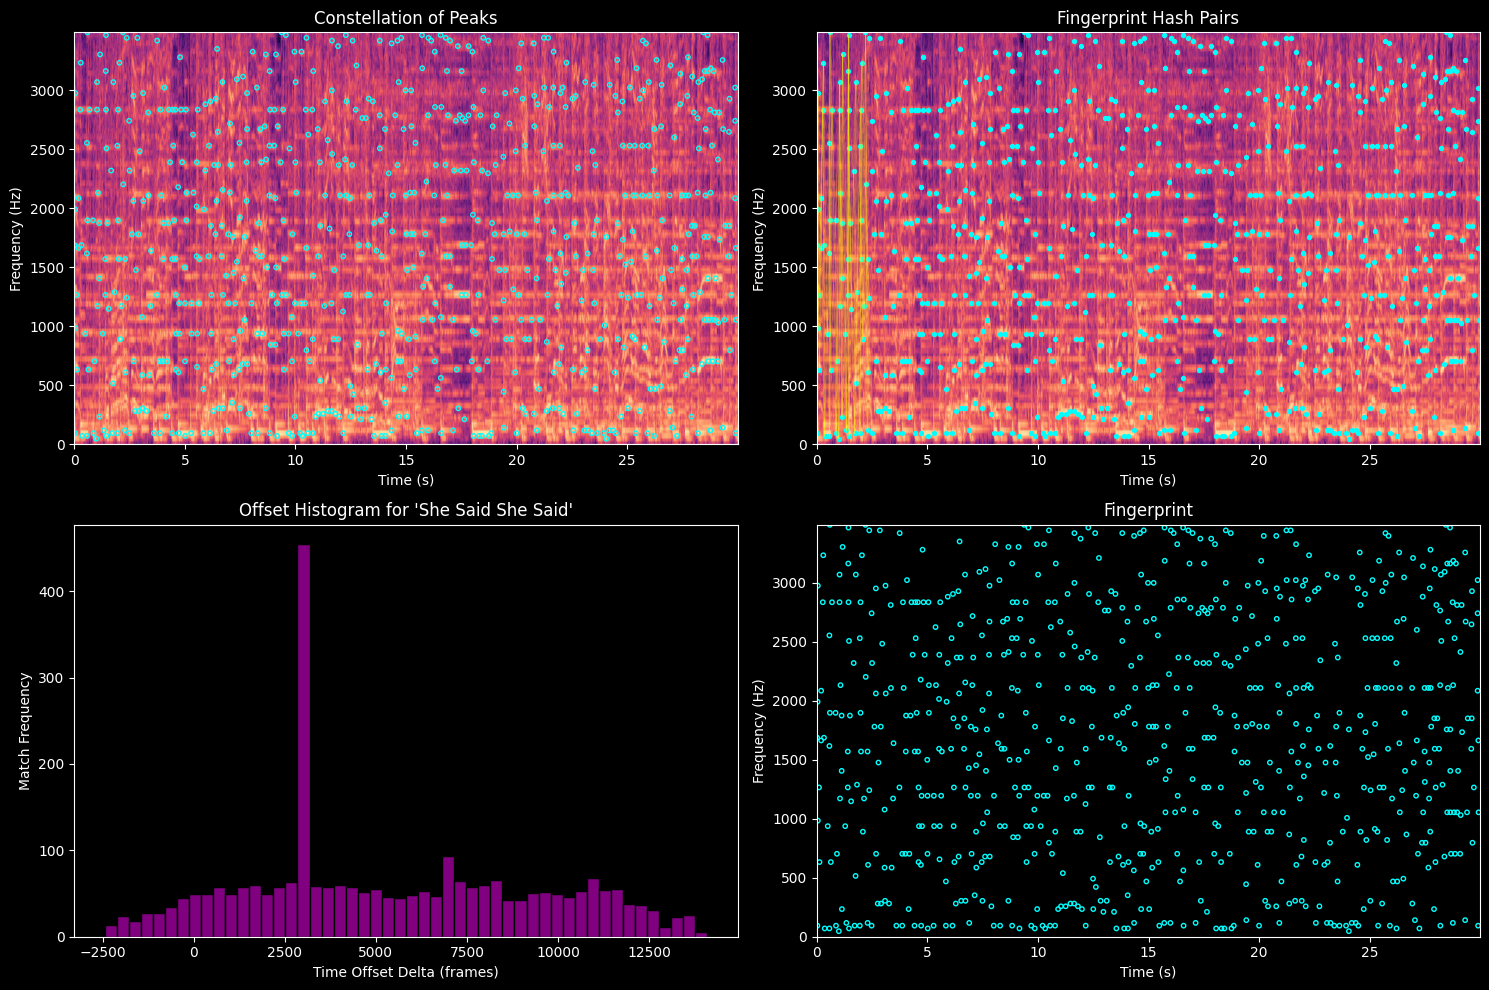

Number of peaks detected: 743


In [13]:
def main():
    # To run inside Jupyter without arg conflicts, we supply a dummy empty list to parse_args
    # In a real script, you'd use parser.parse_args()
    parser = argparse.ArgumentParser(description="EE200 Audio Fingerprinting System")
    parser.add_argument('--songs_dir', type=str, default='./songs', help="Directory with database mp3s")
    parser.add_argument('--query', type=str, default='query_clip.mp3', help="Query audio file")
    parser.add_argument('--rebuild_db', action='store_true', help="Force rebuild of database")
    
    args = parser.parse_args([]) # Pass empty brackets for notebook compatibility 
            
    # Note: For the notebook, ensure you have a 'query_clip.mp3' available
    if os.path.exists(args.query):
        print("\n--- Identifying Query ---")
        y, sr = librosa.load(args.query, sr=None, mono=True)
        prediction, offsets = identify_song(y, sr, database)
        print(f"Result: {prediction}")
        print("\n--- Robustness Experiments ---")
        print("Noise Test:")
        test_noise_robustness(args.query, database)
        
        print("\nPitch Shift Test:")
        test_pitch_shift(args.query, database)

        print("\nTime Stretch Test:")
        test_time_stretch(args.query, database)
        
        print("\n--- Visualization ---")
        plot_full_analysis(args.query, database)
    else:
        print(f"Query file {args.query} not found. Please provide a valid clip.")
    database.clear()

if __name__ == '__main__':
    main()

### Noise Robustness

At high SNR values, most constellation peaks remain visible and the correct song is identified reliably.

As the SNR decreases, random noise introduces spurious peaks and hides genuine spectral peaks, reducing the number of matching hashes.

Recognition eventually fails when the offset histogram no longer exhibits a dominant peak corresponding to the correct song.

### Why Pitch Shift Breaks the Fingerprint

The fingerprint stores exact frequency-bin relationships.

When the entire song is shifted upward in pitch, every spectral peak moves to a different frequency bin.

As a result:

- Original hash: (f1, f2, Δt)
- Shifted hash: (f1+k, f2+k, Δt)

The hashes no longer match the database even though the song sounds very similar to a human listener.

Humans perceive relative musical structure, while this fingerprinting system relies on absolute frequency locations.

### Possible Improvement

Instead of storing absolute frequencies, store frequency ratios or frequency differences between peak pairs.

This would make the fingerprint more tolerant to global pitch shifts because relative relationships between peaks are preserved even when all frequencies move together.

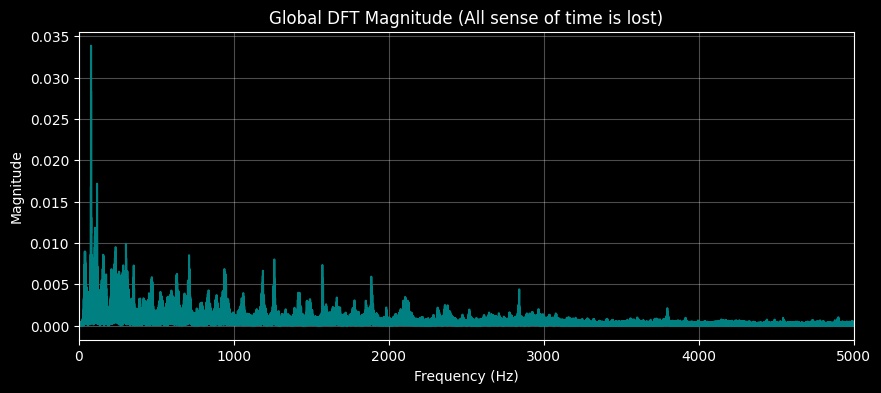

In [14]:
def plot_global_dft(audio_path, duration=15.0):
    y, sr = librosa.load(audio_path, sr=None, mono=True, duration=duration)
    
    # Compute the 1D Fast Fourier Transform for the entire clip
    N = len(y)
    yf = scipy.fft.fft(y)
    xf = scipy.fft.fftfreq(N, 1 / sr)[:N//2]
    magnitude = 2.0/N * np.abs(yf[0:N//2])
    
    plt.figure(figsize=(10, 4))
    plt.plot(xf, magnitude, color='teal')
    plt.title("Global DFT Magnitude (All sense of time is lost)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 5000) # Zoom in on the musically relevant frequencies
    plt.grid(True, alpha=0.3)
    plt.show()

# Run it
plot_global_dft("query_clip.mp3")

## Why a Single DFT is Insufficient

The DFT of the entire song reveals which frequencies are present in the signal, but it completely loses information about when those frequencies occurred.

For example, if a note appears only at the beginning of the song and another appears only at the end, both frequencies still appear together in the global DFT magnitude spectrum.

Therefore, a single Fourier transform provides frequency information but not temporal information.

To track how frequencies evolve over time, we use the Short-Time Fourier Transform (STFT), which computes a Fourier transform on many short overlapping windows. Stacking these transforms produces a spectrogram, where:

- Horizontal axis → Time
- Vertical axis → Frequency
- Color intensity → Magnitude

This time-frequency representation forms the basis of audio fingerprinting systems such as Shazam.

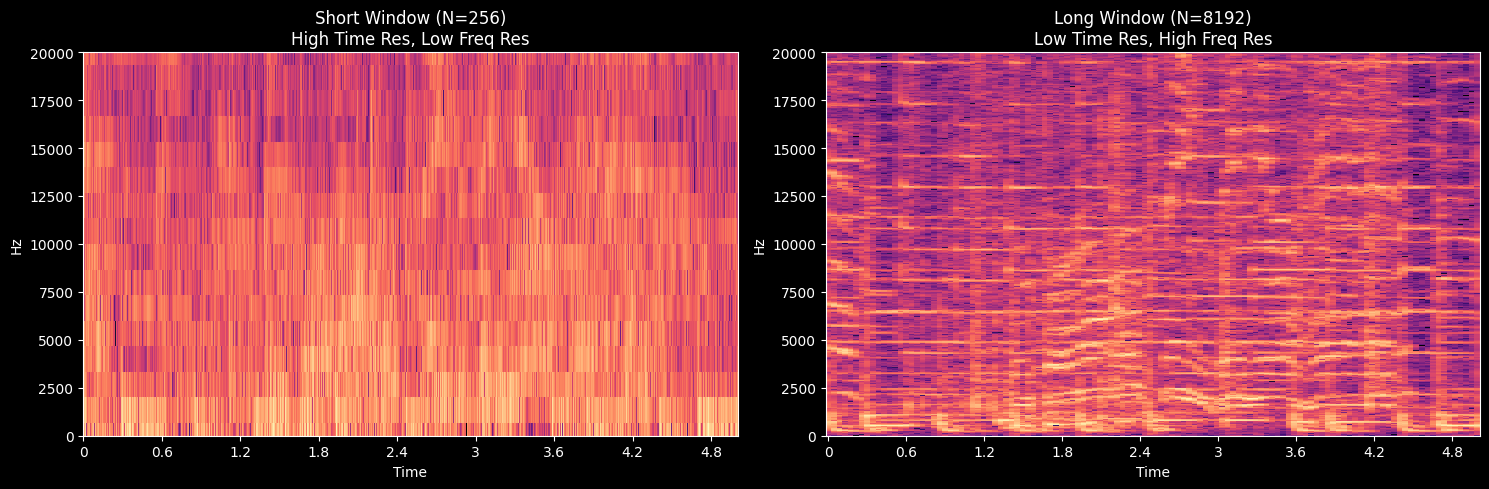

In [15]:
def plot_window_comparison(audio_path, duration=5.0):
    # Load an even shorter clip so the transients are highly visible
    y, sr = librosa.load(audio_path, sr=None, mono=True, duration=duration)
    
    # Short Window (Good Time, Bad Freq)
    S_short, _, _, _, _ = compute_spectrogram(y=y, sr=sr, window_length=256, hop_length=64,max_freq=3500)
    # Long Window (Bad Time, Good Freq)
    S_long, _, _, _, _ = compute_spectrogram(y=y, sr=sr, window_length=8192, hop_length=2048,max_freq=3500)
    
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    
    img1 = librosa.display.specshow(S_short, sr=sr, x_axis='time', y_axis='hz', ax=axs[0], cmap='magma', hop_length=64)
    axs[0].set_title("Short Window (N=256)\nHigh Time Res, Low Freq Res")
    axs[0].set_ylim(0, 20000)  # Limit frequency axis to musically relevant range
    
    img2 = librosa.display.specshow(S_long, sr=sr, x_axis='time', y_axis='hz', ax=axs[1], cmap='magma', hop_length=2048)
    axs[1].set_title("Long Window (N=8192)\nLow Time Res, High Freq Res")
    axs[1].set_ylim(0, 20000)  # Limit frequency axis to musically relevant range

    
    plt.tight_layout()
    plt.show()

# Run it
plot_window_comparison("query_clip.mp3")

### Single Peaks vs Paired Hashes

Single peaks are not very distinctive because many songs share strong energy at common frequencies.

As a result, many accidental matches occur and the offset histogram becomes widely scattered.

Paired hashes combine:

- Anchor frequency
- Target frequency
- Time difference

This additional structure dramatically reduces false matches.

For the correct song, many matched hashes agree on a common time offset, producing a sharp histogram peak. Incorrect songs generate only random scattered offsets.

Therefore paired hashes provide much stronger discriminative power than isolated spectral peaks.

## Time-Frequency Resolution Tradeoff

Two spectrograms were generated:

| Window Length | Observation |
|---------------|-------------|
| 256 samples | Excellent time localization, but frequency bands appear thick and blurry |
| 8192 samples | Sharp frequency localization, but rapid changes become smeared across time |

This demonstrates the uncertainty principle of time-frequency analysis:

- Short windows → good time resolution, poor frequency resolution
- Long windows → good frequency resolution, poor time resolution

Since audio fingerprints depend on stable frequency peaks, a moderately long window is typically preferred.

Identifying query...


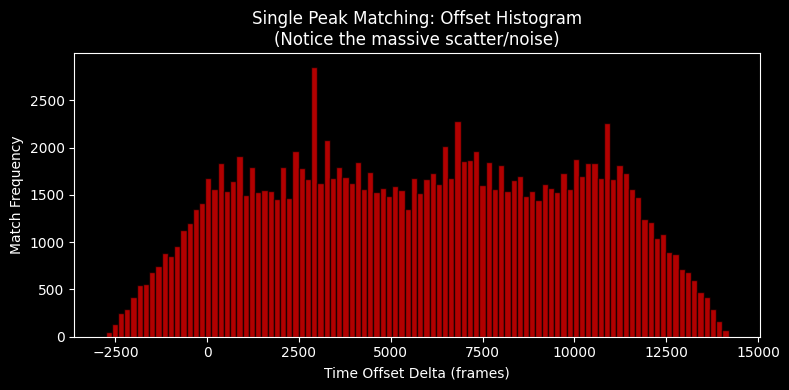

In [16]:
def plot_single_peak_baseline(query_path, songs_dir):
    # 1. Check if the database already exists to save time

    # 2. Run the identification
    print("Identifying query...")
    y, sr = librosa.load(query_path, sr=None, mono=True)
    
    # Make sure to pass use_pairs=False to your identify_song function so it generates single hashes
    prediction, offsets = identify_song(y, sr, db_single, use_pairs=False)
    
    # 3. Plot the results
    plt.figure(figsize=(8, 4))
    if offsets:
        plt.hist(offsets, bins=100, color='red', edgecolor='black', alpha=0.7)
        plt.title("Single Peak Matching: Offset Histogram\n(Notice the massive scatter/noise)")
        plt.xlabel("Time Offset Delta (frames)")
        plt.ylabel("Match Frequency")
    else:
        plt.text(0.5, 0.5, "No Matches", ha='center', va='center')
        plt.title("Single Peak Matching: Offset Histogram")
        
    plt.tight_layout()
    plt.show()
    db_single.clear()

# Run it! (Make sure to replace "./songs" with your actual mp3 folder path)
plot_single_peak_baseline("query_clip.mp3", "./songs")

In [17]:
def evaluate_database(song_folder, database):
    songs = glob.glob(os.path.join(song_folder, "*.mp3"))

    for x in [1,5,9,15]: # Test from 1 to 15 seconds
        correct = 0
        for song in songs:
            y, sr = librosa.load(song, sr=None, duration=x) # Load only the first x seconds for evaluation

            pred, _ = identify_song(y, sr, database)

            true_label = os.path.basename(song).replace(".mp3","")

            if pred == true_label:
                correct += 1

        acc = correct / len(songs)
        print(f"\n{x} seconds: Accuracy = {acc*100:.2f}%")

    
with open("song_db.pkl", 'rb') as f:
            database = pickle.load(f)
evaluate_database("./songs", database)
database.clear()


1 seconds: Accuracy = 76.00%

5 seconds: Accuracy = 98.00%

9 seconds: Accuracy = 100.00%

15 seconds: Accuracy = 100.00%
